# 01. Demographics & Dwellings Analysis

This notebook explores the population and dwelling characteristics of Nørrebro's sub-neighbourhoods.

**Data Sources:**
- `data/processed/norrebro_boundary.gpkg`: Sub-neighbourhood geometries.
- `data/processed/norrebro_neighbourhoods_population.csv`: Population counts by age.
- `data/processed/norrebro_neighbourhoods_dwellings.csv`: Dwelling types and household sizes.

**Goals:**
1. Join granular population data to spatial boundaries using `gm_id`.
2. Visualize population density.
3. Analyze age distribution (Population Pyramids).
4. Explore household composition.

In [50]:
import sys
from pathlib import Path

# Add project root to sys.path
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import geopandas as gpd
import contextily as ctx

# Import custom style
from src.visualization import style

style.apply_style()

## 1. Load Data

In [51]:
# Paths
data_dir = project_root / "data" / "processed"
boundary_path = data_dir / "norrebro_boundary.gpkg"
pop_path = data_dir / "norrebro_neighbourhoods_population.csv"
dwell_path = data_dir / "norrebro_neighbourhoods_dwellings.csv"

# Load
gdf_boundary = gpd.read_file(boundary_path, layer="neighbourhoods")
df_pop = pd.read_csv(pop_path)
df_dwell = pd.read_csv(dwell_path)

print("Boundary Columns:", gdf_boundary.columns.tolist())
print("Population Columns:", df_pop.columns.tolist())
print("Dwellings Columns:", df_dwell.columns.tolist())

Boundary Columns: ['neighbourhood_name', 'geometry']
Population Columns: ['gm_id', 'period', 'ages', 'neighbourhood', 'people']
Dwellings Columns: ['gm_id', 'neighbourhood', 'year', 'dwelling_type', 'household_persons', 'units']


## 2. Prepare Population Data
Aggregate population by `gm_id` to get total counts per sub-neighbourhood.

In [52]:
gdf_boundary.index.to_list()

[0, 1, 2, 3, 4]

In [53]:
# Inspect unique gm_ids to ensure they match
print("Boundary Index:", gdf_boundary.index.to_list())
print("Population IDs:", df_pop["gm_id"].unique())
print("Dwellings IDs:", df_dwell["gm_id"].unique())

Boundary Index: [0, 1, 2, 3, 4]
Population IDs: [5 4 1 2 3]
Dwellings IDs: [5 4 1 2 3]


In [54]:
# creating an 'gm_id' column in the boundary GeoDataFrame based on the index +1
gdf_boundary["gm_id"] = gdf_boundary.index + 1


In [55]:
# Aggregate total population per gm_id
pop_col = "people"

total_pop = df_pop.groupby("gm_id")[pop_col].sum().reset_index()
total_pop.rename(columns={pop_col: "total_population"}, inplace=True)

# Join to Geometry
gdf_analysis = gdf_boundary.merge(total_pop, on="gm_id", how="left")

# Calculate Area (km2) & Density
gdf_analysis["area_km2"] = gdf_analysis.geometry.area / 10**6
gdf_analysis["density_per_km2"] = (
    gdf_analysis["total_population"] / gdf_analysis["area_km2"]
)

gdf_analysis.head()

,neighbourhood_name,geometry,gm_id,total_population,area_km2,density_per_km2
0,Stefansgade,"POLYGON ((722265.368 6177970.311, 722271.613 6...",1,17754,0.684061,25953.810762
1,Mimersgade-kvarteret,"POLYGON ((722502.342 6179113.208, 722509.207 6...",2,17372,0.681087,25506.268203
2,Haraldsgade-kvarteret,"POLYGON ((723599.29 6178788.969, 723604.305 61...",3,10188,0.740340,13761.253616
3,Guldbergskvarteret,"POLYGON ((723958.682 6177016.163, 723951.927 6...",4,19761,1.147781,17216.692063
4,Blagardskvarteret,"POLYGON ((722595.063 6176998.544, 722587.78 61...",5,14678,0.854507,17177.161713


## 3. Visualize Population Density

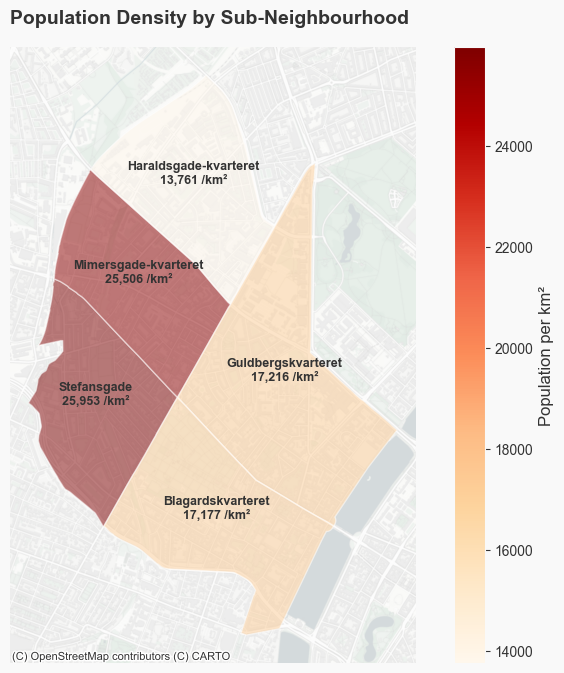

In [56]:
fig, ax = plt.subplots(figsize=(10, 8))

gdf_analysis.plot(
    column="density_per_km2",
    cmap="OrRd",
    legend=True,
    legend_kwds={"label": "Population per km²"},
    edgecolor="white",
    linewidth=1,
    ax=ax,
    alpha=0.5,
)

# Add labels
for idx, row in gdf_analysis.iterrows():
    # Use centroid for labeling
    x, y = row.geometry.centroid.x, row.geometry.centroid.y
    ax.text(
        x,
        y,
        f"{row['neighbourhood_name']}\n{int(row['density_per_km2']):,} /km²",
        ha="center",
        fontsize=9,
        fontweight="bold",
        color=style.PALETTE["text"],
    )

ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, crs="EPSG:25832")
ax.set_title("Population Density by Sub-Neighbourhood", loc="left")
ax.set_axis_off()
plt.show()

## 4. Age Distribution

In [57]:
df_pop.head()

,gm_id,period,ages,neighbourhood,people
0,5,2025Q4,0-4 years,N¯rrebro - BlÂgÂrdskvarteret/Assistens/Rantzau...,824
1,4,2025Q4,0-4 years,N¯rrebro - Guldbergskvarteret/Panum/Ravnsborggade,1077
2,1,2025Q4,0-4 years,N¯rrebro - Stefansgade/N¯rrebroparken/Lundtoft...,1184
3,2,2025Q4,0-4 years,N¯rrebro - Mimersgade-kvarteret/ N¯rrebro St.,985
4,3,2025Q4,0-4 years,N¯rrebro - Haraldsgade-kvarteret,567


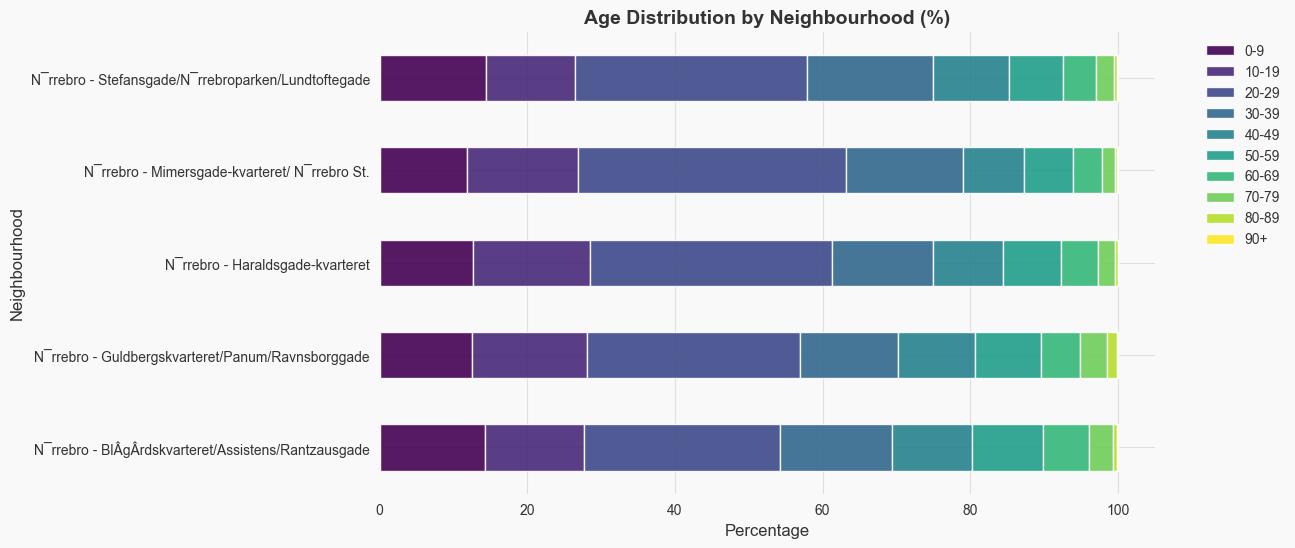

In [58]:
# Check age columns.
# Current notationsare like "0-4 years", "5-9 years", "95+ years"...
age_col = "ages"


# Clean age string if necessary
def clean_age(x):
    if isinstance(x, str):
        x = x.replace(" years", "")
        if x.endswith("+"):
            x = x[:-1]  # Remove the '+' for 95+ to get 95
        if x.split("-")[0].isdigit():
            x = x.split("-")[0]  # Take the lower bound for ranges like "0-4"
    return int(x)


df_pop["age_int"] = df_pop[age_col].apply(clean_age)

# Create age groups of 10 years
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 200]
labels = [
    "0-9",
    "10-19",
    "20-29",
    "30-39",
    "40-49",
    "50-59",
    "60-69",
    "70-79",
    "80-89",
    "90+",
]
df_pop["age_group"] = pd.cut(
    df_pop["age_int"], bins=bins, labels=labels, right=True, include_lowest=True
)

# Aggregate
age_dist = df_pop.groupby(["neighbourhood", "age_group"])[pop_col].sum().unstack()
age_dist_pct = age_dist.div(age_dist.sum(axis=1), axis=0) * 100

# Plot Stacked Bar
ax = age_dist_pct.plot(
    kind="barh", stacked=True, figsize=(10, 6), colormap="viridis", alpha=0.9
)

ax.set_title("Age Distribution by Neighbourhood (%)")
ax.set_xlabel("Percentage")
ax.set_ylabel("Neighbourhood")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
sns.despine()
plt.show()

## 5. Household Analysis
Visualizing dwelling types and household sizes.

In [59]:
# Explore dwelling columns
df_dwell.head()

,gm_id,neighbourhood,year,dwelling_type,household_persons,units
0,5,N¯rrebro - BlÂgÂrdskvarteret/Assistens/Rantzau...,2025,Multi-dwelling houses,1,2692
1,5,N¯rrebro - BlÂgÂrdskvarteret/Assistens/Rantzau...,2025,Multi-dwelling houses,2,2154
2,5,N¯rrebro - BlÂgÂrdskvarteret/Assistens/Rantzau...,2025,Multi-dwelling houses,3,1005
3,5,N¯rrebro - BlÂgÂrdskvarteret/Assistens/Rantzau...,2025,Multi-dwelling houses,4,661
4,5,N¯rrebro - BlÂgÂrdskvarteret/Assistens/Rantzau...,2025,Multi-dwelling houses,5,207


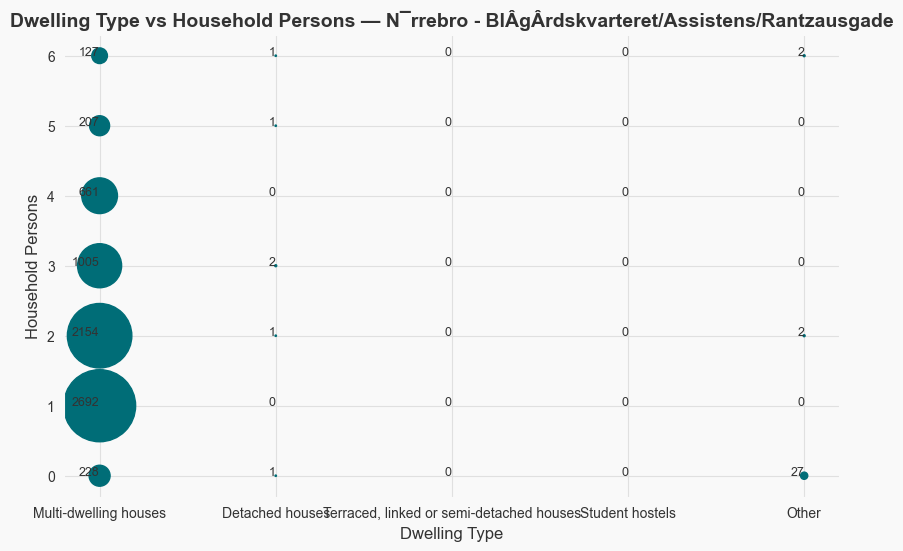

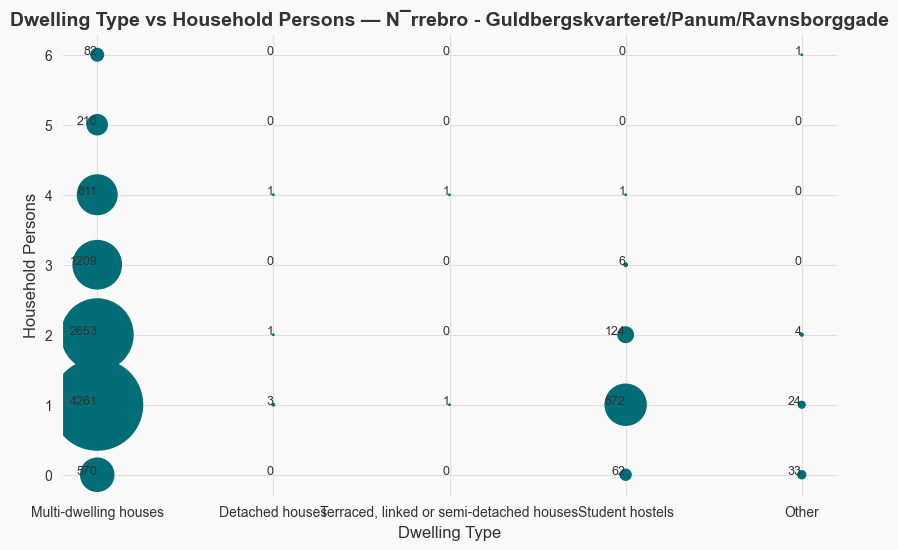

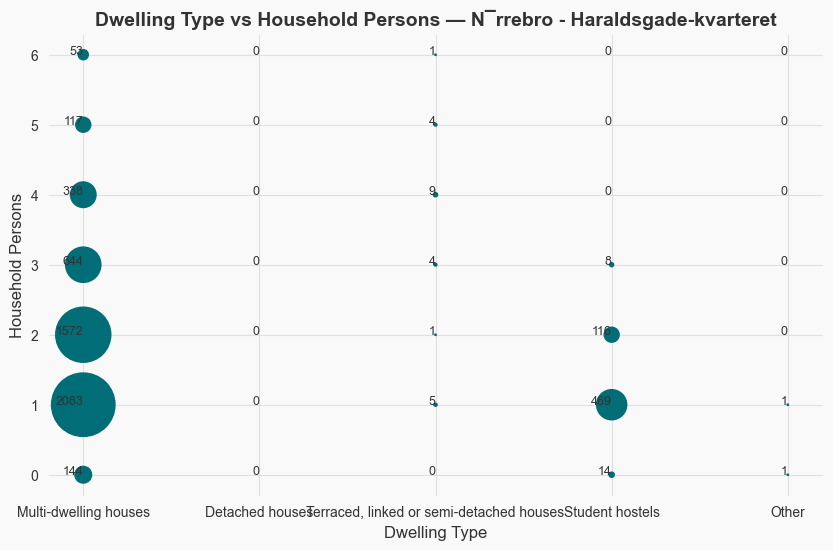

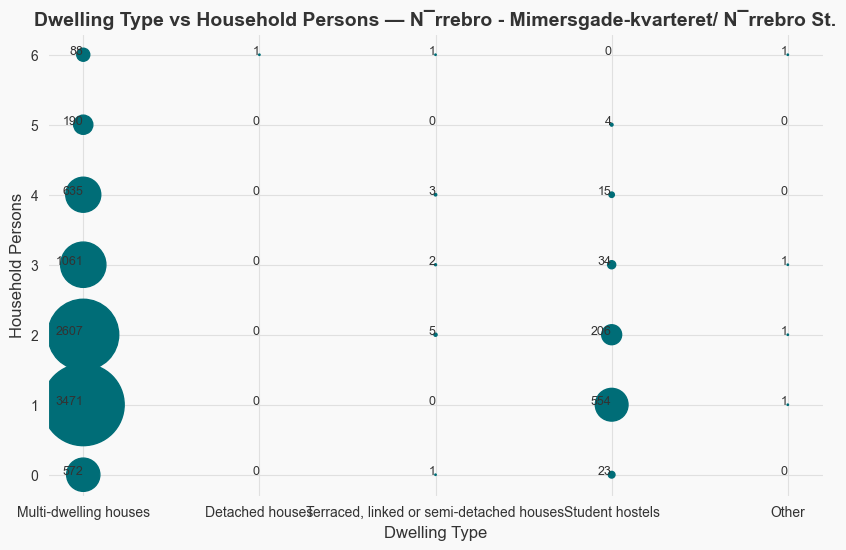

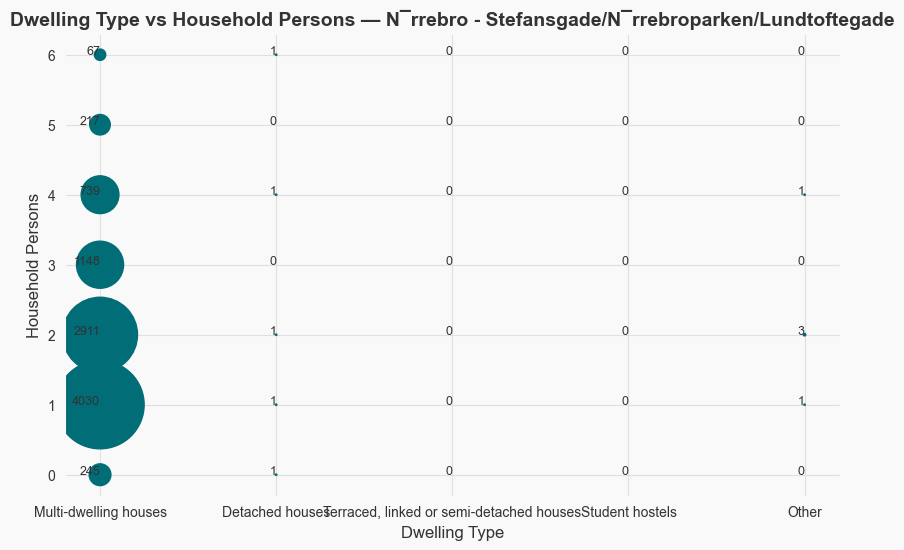

In [70]:
# explore the relationship between 'dwelling_type' (eg. "Multi-dwelling houses") and 'household_persons' (1,2,3, etc.)

# create one chart per neighbourhood
for neighbourhood, group in df_dwell.groupby("neighbourhood"):
    ax = group.plot(
        x="dwelling_type",
        y="household_persons",
        kind="scatter",
        s=group["units"],
        figsize=(10, 6),
    )
    for _, row in group.iterrows():
        ax.text(
            row["dwelling_type"],
            row["household_persons"],
            str(row["units"]),
            fontsize=9,
            ha="right",
        )

    ax.set_title(f"Dwelling Type vs Household Persons — {neighbourhood}")
    ax.set_xlabel("Dwelling Type")
    ax.set_ylabel("Household Persons")
    plt.show()

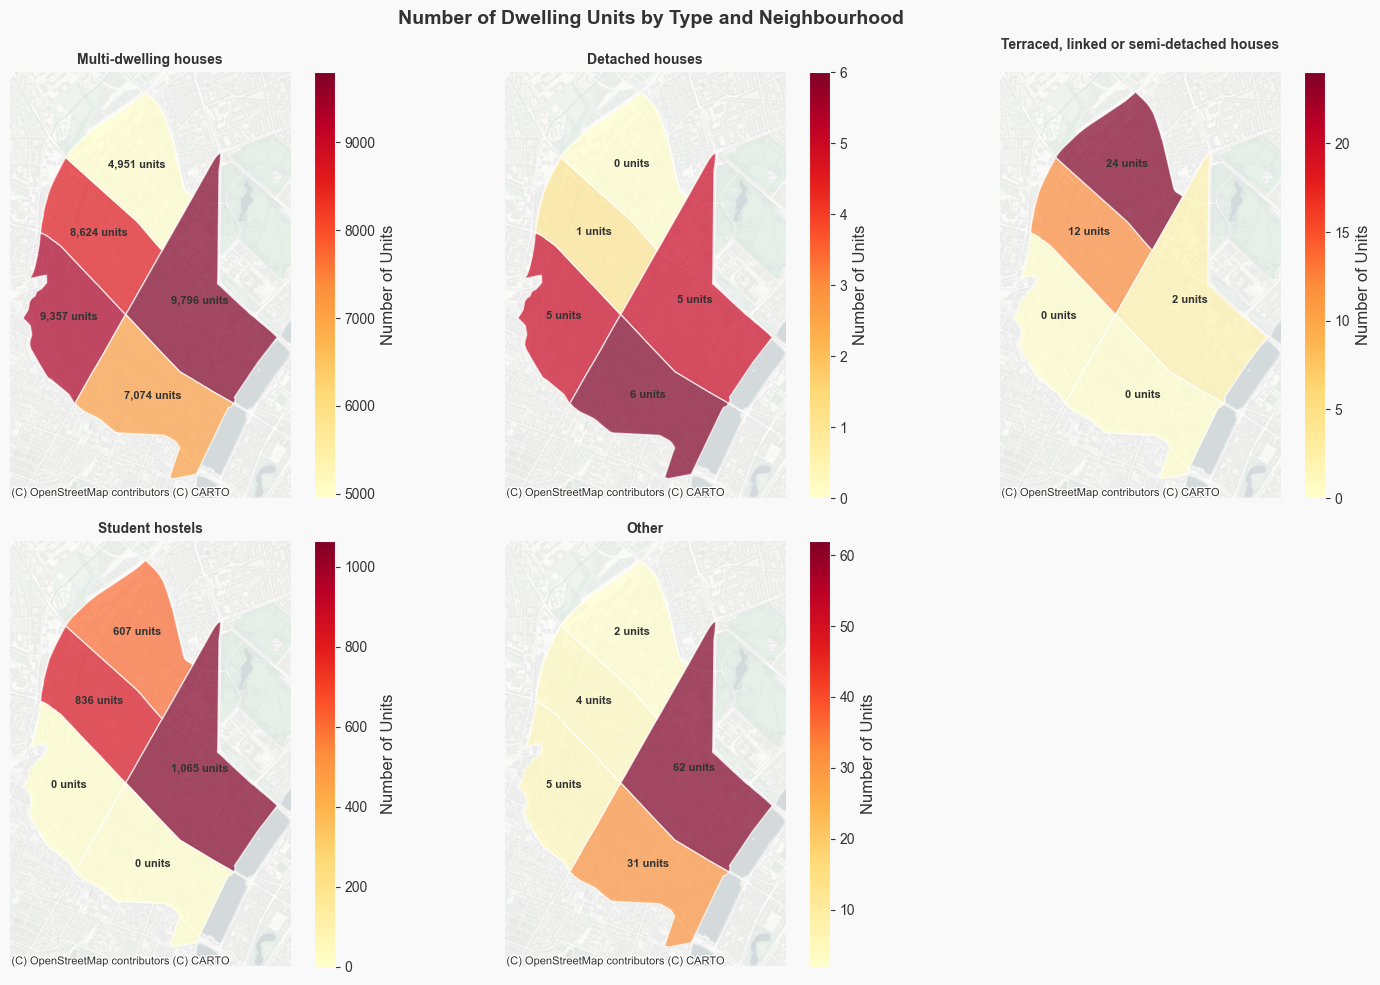

In [ ]:
# Get unique dwelling types
dwelling_types = df_dwell["dwelling_type"].unique()

# Create subplots - arrange in grid
n_types = len(dwelling_types)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, dwelling_type in enumerate(dwelling_types):
    # Aggregate units by gm_id for this dwelling type
    dwell_type_data = (
        df_dwell[df_dwell["dwelling_type"] == dwelling_type]
        .groupby("gm_id")["units"]
        .sum()
        .reset_index()
    )

    # Merge with boundary data
    gdf_plot = gdf_boundary.merge(dwell_type_data, on="gm_id", how="left")
    gdf_plot["units"] = gdf_plot["units"].fillna(0)

    # Plot
    gdf_plot.plot(
        column="units",
        cmap="YlOrRd",
        legend=True,
        legend_kwds={"label": "Number of Units"},
        edgecolor="white",
        linewidth=1,
        ax=axes[i],
        alpha=0.7,
    )

    # Add basemap
    ctx.add_basemap(
        axes[i], source=ctx.providers.CartoDB.PositronNoLabels, crs="EPSG:25832"
    )
    # Add labels
    for idx, row in gdf_plot.iterrows():
        x, y = row.geometry.centroid.x, row.geometry.centroid.y
        axes[i].text(
            x,
            y,
            f"{int(row['units']):,} units",
            ha="center",
            fontsize=8,
            fontweight="bold",
            color=style.PALETTE["text"],
        )

    # Set title
    axes[i].set_title(f"{dwelling_type}", fontsize=10, fontweight="bold")
    axes[i].set_axis_off()

# Remove extra subplot if odd number
if n_types < len(axes):
    for j in range(n_types, len(axes)):
        fig.delaxes(axes[j])

plt.suptitle(
    "Number of Dwelling Units by Type and Neighbourhood",
    fontsize=14,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout()
plt.show()